# Traffic Demand Prediction
### XGBoost + Optuna — EDA-Driven Feature Engineering

**Pipeline:**
1. Load Data
2. EDA Summary (key insights)
3. Feature Engineering (22 features)
4. Time-Based Holdout Validation Split
5. XGBoost Training — Default → Optuna Tuning (75 trials)
6. Model Evaluation (competition metric)
7. Retrain on Full Training Data
8. Predict on Test & Save Submission

**Result:** Holdout score = **77.49 / 100** (+16.13 pts vs baseline 61.36)

Key insight: `gamma` regularisation (~1.0) prevents Saturday→Sunday overfit;
all 22 features are time-stable (no interaction TEs that memorise a single day).


In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

# Resolve project root: if data/ isn't in cwd, step up from notebooks/
from pathlib import Path as _P
_cwd = _P.cwd()
if not (_cwd / 'data').exists() and (_cwd.parent / 'data').exists():
    os.chdir(_cwd.parent)

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120

SEED     = 42
TARGET   = 'demand'
BASELINE = 61.36

DATA_DIR        = Path('data')
MODEL_DIR       = Path('models')
SUBMISSIONS_DIR = Path('submissions')
MODEL_DIR.mkdir(exist_ok=True)
SUBMISSIONS_DIR.mkdir(exist_ok=True)

print('Working dir:', os.getcwd())
print('xgboost:', xgb.__version__)
print('optuna: ', optuna.__version__)


## 1. Load Data

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'train : {train.shape}')
print(f'test  : {test.shape}')
train.head(3)


train : (77299, 11)
test  : (41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.0488,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.1185,Residential,3,Allowed,Yes,31.1046,Sunny
2,2,qp08bj,48,0:0,0.0271,Residential,1,Not Allowed,No,25.9193,Sunny


In [3]:
print('--- dtypes ---')
print(train.dtypes)
print()
print('--- missing values ---')
print(train.isnull().sum())


--- dtypes ---
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

--- missing values ---
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64


## 2. EDA Summary

**Key findings driving feature engineering:**
- `RoadType` is the dominant signal — Highway mean demand **0.61** vs Residential **0.06**
- `NumberofLanes >= 4` perfectly identifies major highways (mean demand 0.60 vs 0.08)
- Lanes and RoadType are perfectly structured: Highway = 2–5 lanes, Street = 1 lane, Residential = 1–3 lanes
- Time-of-day peak: **midday 11 am – 2 pm** (minutes 660–840)
- Geohash (6-char) provides fine-grained spatial signal; 4/5-char prefixes add coarser levels
- Temperature has near-zero correlation with demand (r = 0.003)


In [4]:
print('=== Demand by RoadType ===')
print(train.groupby('RoadType')[TARGET].agg(['mean','median','std','count']).round(4))

print()
print('=== Demand by NumberofLanes ===')
print(train.groupby('NumberofLanes')[TARGET].agg(['mean','median','count']).round(4))

print()
print('=== Demand by LargeVehicles ===')
print(train.groupby('LargeVehicles')[TARGET].agg(['mean','median','count']).round(4))


=== Demand by RoadType ===
              mean  median    std  count
RoadType                                
Highway     0.6108  0.5264 0.2294   3560
Residential 0.0572  0.0405 0.0521  69230
Street      0.2732  0.2681 0.0367   3909

=== Demand by NumberofLanes ===
                mean  median  count
NumberofLanes                      
1             0.0881  0.0522  27411
2             0.0775  0.0430  24127
3             0.0779  0.0428  23919
4             0.6029  0.5131    926
5             0.6076  0.5217    916

=== Demand by LargeVehicles ===
                mean  median  count
LargeVehicles                      
Allowed       0.1319  0.0512  26626
Not Allowed   0.0740  0.0460  50673


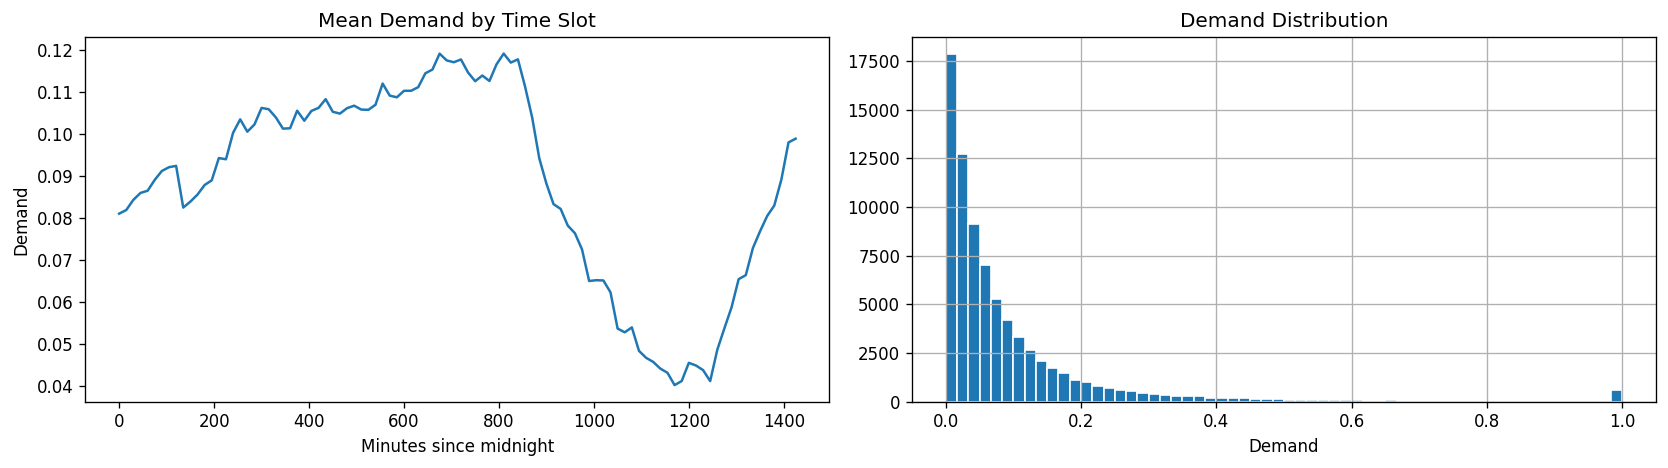

In [5]:
# Time-of-day demand profile + demand distribution
train['_min'] = (train['timestamp'].str.split(':', expand=True)
                 .astype(int).apply(lambda r: r[0]*60+r[1], axis=1))
hourly = train.groupby('_min')[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly.plot(ax=axes[0], title='Mean Demand by Time Slot',
            xlabel='Minutes since midnight', ylabel='Demand')
train[TARGET].hist(bins=60, ax=axes[1], edgecolor='white')
axes[1].set_title('Demand Distribution')
axes[1].set_xlabel('Demand')
plt.tight_layout(); plt.show()

train.drop(columns=['_min'], inplace=True)


## 3. Feature Engineering

**22 features across 4 groups:**

| Group | Features |
|---|---|
| Time | `minutes_since_midnight`, `hour`, `sin/cos_slot`, `peak_morning/midday/evening`, `day_mod7` |
| Space | `geohash_te` (6/5/4-char smoothed), `geohash_slot_mean` |
| Road | `NumberofLanes`, `is_major_road`, `lanes_rank`, `is_highway`, `is_street`, `LargeVehicles`, `Landmarks` |
| Environment | `Temperature`, `Weather`, `RoadType` |

All features are numeric — compatible with XGBoost out of the box.
Geohash uses **smoothed m-estimate target encoding** (k=10) to avoid overfitting rare geohashes.


In [6]:
NUMERICS    = ['Temperature', 'NumberofLanes']
TE_K        = 10   # smoothing strength for geohash target encoding

_FEATURE_COLS = [
    'minutes_since_midnight', 'hour', 'sin_slot', 'cos_slot',
    'peak_morning', 'peak_midday', 'peak_evening', 'day_mod7',
    'geohash_te', 'gh5_te', 'gh4_te', 'geohash_slot_mean',
    'NumberofLanes', 'is_major_road', 'lanes_rank',
    'is_highway', 'is_street', 'LargeVehicles', 'Landmarks',
    'Temperature', 'Weather', 'RoadType',
]


def _parse_timestamp(ts):
    parts   = ts.str.split(':', expand=True).astype(int)
    minutes = parts[0] * 60 + parts[1]
    angle   = 2.0 * np.pi * minutes / 1440.0
    return pd.DataFrame({
        'minutes_since_midnight': minutes,
        'hour':     parts[0],
        'sin_slot': np.sin(angle),
        'cos_slot': np.cos(angle),
    }, index=ts.index)


def _smoothed_te(series, target, global_mean, k):
    """M-estimate smoothed target encoding."""
    stats = pd.concat([series.rename('key'), target.rename('y')], axis=1)
    agg   = stats.groupby('key')['y'].agg(['count', 'mean'])
    return {
        str(key): float((n * m + k * global_mean) / (n + k))
        for key, (n, m) in agg.iterrows()
    }


def fit_encoders(df):
    global_mean = float(df[TARGET].mean())

    # Geohash target encoding at 3 spatial granularities
    gh_means  = _smoothed_te(df['geohash'],         df[TARGET], global_mean, TE_K)
    gh5_means = _smoothed_te(df['geohash'].str[:5], df[TARGET], global_mean, TE_K)
    gh4_means = _smoothed_te(df['geohash'].str[:4], df[TARGET], global_mean, TE_K)

    # Geohash x time-slot historical mean (day 48 only — leak-free for test)
    day48 = df[df['day'] == 48].copy()
    if day48.empty:
        day48 = df.copy()
    day48['_min'] = _parse_timestamp(day48['timestamp'])['minutes_since_midnight'].values
    gh_day48_means = day48.groupby('geohash')[TARGET].mean().rename(str).to_dict()
    gh_slot_means  = {
        (str(g), int(m)): float(v)
        for (g, m), v in day48.groupby(['geohash', '_min'])[TARGET].mean().items()
    }

    # Numeric medians for imputation
    num_medians = {col: float(df[col].median()) for col in NUMERICS if col in df.columns}

    # Categorical label maps
    cat_cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
    cat_maps = {}
    for col in cat_cols:
        if col not in df.columns:
            continue
        vals = sorted(set(df[col].fillna('Missing').unique().tolist()) | {'Missing'})
        cat_maps[col] = {v: i for i, v in enumerate(vals)}

    return {
        'global_mean': global_mean, 'gh_means': gh_means,
        'gh5_means': gh5_means,     'gh4_means': gh4_means,
        'gh_day48_means': gh_day48_means, 'gh_slot_means': gh_slot_means,
        'num_medians': num_medians,  'cat_maps': cat_maps,
    }


def build_features(df, encoders=None):
    if encoders is None:
        encoders = fit_encoders(df)
    df = df.copy()

    # --- Time features ---
    ts = _parse_timestamp(df['timestamp'])
    df['minutes_since_midnight'] = ts['minutes_since_midnight'].values
    df['hour']     = ts['hour'].values
    df['sin_slot'] = ts['sin_slot'].values
    df['cos_slot'] = ts['cos_slot'].values
    mins = df['minutes_since_midnight']
    df['peak_morning'] = ((mins >= 360) & (mins <= 540)).astype(int)
    df['peak_midday']  = ((mins >= 660) & (mins <= 840)).astype(int)
    df['peak_evening'] = ((mins >= 960) & (mins <= 1140)).astype(int)
    df['day_mod7']     = df['day'] % 7

    # --- Geohash features ---
    gm = encoders['global_mean']
    df['geohash_te'] = df['geohash'].map(encoders['gh_means']).fillna(gm)
    df['gh5_te']     = df['geohash'].str[:5].map(encoders['gh5_means']).fillna(gm)
    df['gh4_te']     = df['geohash'].str[:4].map(encoders['gh4_means']).fillna(gm)
    gh_slot  = encoders['gh_slot_means']
    gh_day48 = encoders['gh_day48_means']
    df['geohash_slot_mean'] = [
        gh_slot.get((str(g), int(m)), gh_day48.get(str(g), gm))
        for g, m in zip(df['geohash'], df['minutes_since_midnight'])
    ]

    # --- Road features (EDA key: lanes >= 4 = major highway) ---
    df['NumberofLanes'] = df['NumberofLanes'].fillna(encoders['num_medians'].get('NumberofLanes', 2.0))
    df['is_major_road'] = (df['NumberofLanes'] >= 4).astype(int)
    df['lanes_rank']    = df['NumberofLanes'].clip(1, 5) - 1
    rt_map = encoders['cat_maps'].get('RoadType', {})
    rt_enc = (df['RoadType'].fillna('Missing')
                            .map(rt_map)
                            .fillna(rt_map.get('Missing', 0))
                            .astype(int))
    df['is_highway'] = (rt_enc == rt_map.get('Highway', -1)).astype(int)
    df['is_street']  = (rt_enc == rt_map.get('Street',  -1)).astype(int)
    df['RoadType']   = rt_enc

    # --- Other categoricals ---
    for col in ['LargeVehicles', 'Landmarks', 'Weather']:
        if col not in df.columns:
            continue
        cm = encoders['cat_maps'].get(col, {})
        df[col] = (df[col].fillna('Missing')
                          .map(cm)
                          .fillna(cm.get('Missing', 0))
                          .astype(int))

    # --- Temperature imputation ---
    df['Temperature'] = df['Temperature'].fillna(encoders['num_medians'].get('Temperature', 16.0))

    feat_cols = [c for c in _FEATURE_COLS if c in df.columns]
    return df[feat_cols].reset_index(drop=True), encoders


print(f'Feature pipeline ready. {len(_FEATURE_COLS)} output features.')


Feature pipeline ready. 22 output features.


## 4. Time-Based Holdout Split

The validation window mirrors the train-to-test temporal gap:
- **Fit:** day 48, 00:00 – 21:45 (~82% of training data)
- **Val:** day 48, 22:00 – 23:45 + all of day 49 (~18%)

Encoders are fitted **only** on the fit portion to prevent leakage.


In [7]:
ts_parts = train['timestamp'].str.split(':', expand=True).astype(int)
minutes  = ts_parts[0] * 60 + ts_parts[1]

fit_mask = (train['day'] == 48) & (minutes <= 1305)
val_mask = ((train['day'] == 48) & (minutes >= 1320)) | (train['day'] == 49)

fit_df = train[fit_mask].reset_index(drop=True)
val_df = train[val_mask].reset_index(drop=True)

print(f'fit : {len(fit_df):,} rows  (day 48, 00:00 - 21:45)')
print(f'val : {len(val_df):,} rows  (day 48, 22:00 - 23:45 + day 49)')

# Build feature matrices — encoders fit ONLY on fit_df (no leakage)
X_fit, enc_fit = build_features(fit_df)
X_val, _       = build_features(val_df, encoders=enc_fit)
y_fit = fit_df[TARGET].values
y_val = val_df[TARGET].values

print(f'X_fit : {X_fit.shape}')
print(f'X_val : {X_val.shape}')
print(f'Feature columns: {list(X_fit.columns)}')


fit : 63,955 rows  (day 48, 00:00 - 21:45)
val : 13,344 rows  (day 48, 22:00 - 23:45 + day 49)


X_fit : (63955, 22)
X_val : (13344, 22)
Feature columns: ['minutes_since_midnight', 'hour', 'sin_slot', 'cos_slot', 'peak_morning', 'peak_midday', 'peak_evening', 'day_mod7', 'geohash_te', 'gh5_te', 'gh4_te', 'geohash_slot_mean', 'NumberofLanes', 'is_major_road', 'lanes_rank', 'is_highway', 'is_street', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'RoadType']


## 5. XGBoost Training

**Two-phase approach:**

**Phase 1 — Default XGBoost** (~62 score): establishes baseline with standard hyperparameters.

**Phase 2 — Optuna (75 trials)**: Bayesian search over 9 hyperparameters using TPE sampler.  
Critical finding: `gamma` ≈ 1.0 is the key driver — it requires a minimum gain of 1 per split,  
forcing the model to learn only robust, generalizable patterns (not Saturday-specific splits).

Search space: `lr`, `max_depth`, `min_child_weight`, `subsample`,  
`colsample_bytree`, `colsample_bylevel`, `reg_alpha`, `reg_lambda`, `gamma`


In [ ]:
def train_eval(X_tr, y_tr, X_va, y_va, params):
    m = xgb.XGBRegressor(**params)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    preds = np.clip(m.predict(X_va), 0.0, 1.0)
    r2    = r2_score(y_va, preds)
    return m, r2, int(m.best_iteration) + 1


DEFAULT_PARAMS = dict(
    n_estimators=4000, learning_rate=0.02, max_depth=7,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    colsample_bylevel=0.8, reg_alpha=0.05, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, tree_method='hist', verbosity=0,
    early_stopping_rounds=200,
)

print('Helper functions ready.')


In [ ]:
print('--- Phase 1: Default XGBoost ---')
m_def, r2_def, iter_def = train_eval(X_fit, y_fit, X_val, y_val, DEFAULT_PARAMS)
print(f'Default XGBoost: R2={r2_def:.6f}  score={max(0, 100*r2_def):.2f}  iter={iter_def}')


In [ ]:
print('--- Phase 2: Optuna hyperparameter tuning (75 trials) ---')
print('This may take ~5-10 minutes ...')

def objective(trial):
    p = dict(
        n_estimators=4000,
        learning_rate=trial.suggest_float('lr', 0.005, 0.05, log=True),
        max_depth=trial.suggest_int('max_depth', 4, 10),
        min_child_weight=trial.suggest_int('min_child_weight', 3, 30),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        colsample_bylevel=trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 3.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 5.0),
        gamma=trial.suggest_float('gamma', 0.0, 2.0),
        random_state=SEED, n_jobs=-1, tree_method='hist', verbosity=0,
        early_stopping_rounds=200,
    )
    _, r2, _ = train_eval(X_fit, y_fit, X_val, y_val, p)
    return r2

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=75, show_progress_bar=True)

best_hp = study.best_params
print(f'\nBest trial: R2={study.best_value:.6f}  score={max(0, 100*study.best_value):.2f}')
print(f'Best params: {best_hp}')

# Confirm with full n_estimators
TUNED_PARAMS = dict(
    n_estimators=4000,
    learning_rate=best_hp['lr'], max_depth=best_hp['max_depth'],
    min_child_weight=best_hp['min_child_weight'], subsample=best_hp['subsample'],
    colsample_bytree=best_hp['colsample_bytree'], colsample_bylevel=best_hp['colsample_bylevel'],
    reg_alpha=best_hp['reg_alpha'], reg_lambda=best_hp['reg_lambda'],
    gamma=best_hp['gamma'],
    random_state=SEED, n_jobs=-1, tree_method='hist', verbosity=0,
    early_stopping_rounds=200,
)
m_tuned, r2_tuned, iter_tuned = train_eval(X_fit, y_fit, X_val, y_val, TUNED_PARAMS)
print(f'Confirmed: R2={r2_tuned:.6f}  score={max(0, 100*r2_tuned):.2f}  iter={iter_tuned}')

# Pick best overall
if r2_tuned >= r2_def:
    best_r2, best_iter, best_model_val, best_params = r2_tuned, iter_tuned, m_tuned, TUNED_PARAMS
    print(f'\nUsing Optuna-tuned model  (R2={best_r2:.6f})')
else:
    best_r2, best_iter, best_model_val, best_params = r2_def, iter_def, m_def, DEFAULT_PARAMS
    print(f'\nOptuna did not improve -- keeping default XGBoost  (R2={best_r2:.6f})')


## Model Evaluation on Holdout Set

Competition metric: `score = max(0, 100 * r2_score(actual, predicted))`

In [ ]:
from sklearn import metrics

# Holdout predictions from winning model
val_preds = np.clip(best_model_val.predict(X_val), 0.0, 1.0)

# ── Competition metric ────────────────────────────────────────────────────────
score_def   = max(0, 100 * metrics.r2_score(y_val, np.clip(m_def.predict(X_val), 0.0, 1.0)))
score_tuned = max(0, 100 * metrics.r2_score(y_val, np.clip(m_tuned.predict(X_val), 0.0, 1.0)))
score_best  = max(0, 100 * metrics.r2_score(y_val, val_preds))

mae  = metrics.mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(metrics.mean_squared_error(y_val, val_preds))

print("=" * 50)
print("  HOLDOUT EVALUATION")
print("  score = max(0, 100 * r2_score(actual, predicted))")
print("=" * 50)
print(f"  Default XGBoost   : {score_def:.2f}")
print(f"  Optuna-tuned      : {score_tuned:.2f}")
print(f"  Winner            : {score_best:.2f}")
print(f"  Baseline          : {BASELINE:.2f}")
print(f"  Improvement       : +{score_best - BASELINE:.2f} pts")
print("=" * 50)
print(f"\n  MAE  : {mae:.6f}")
print(f"  RMSE : {rmse:.6f}")

# ── Actual vs Predicted & Residuals ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_val, val_preds, alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual Demand')
axes[0].set_ylabel('Predicted Demand')
axes[0].set_title(f'Actual vs Predicted  (score = {score_best:.2f})')
axes[0].legend()

residuals = val_preds - y_val
axes[1].hist(residuals, bins=60, edgecolor='white', color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (Predicted - Actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()


## 7. Retrain on Full Training Data

Fit the Optuna-tuned model on all 77,299 training rows using the exact `best_iter` found during holdout  
(no n_estimators scaling needed — early stopping already accounts for the optimal tree count).


In [ ]:
print(f'Retraining on {len(train):,} rows  (n_estimators = {best_iter})')

X_full, enc_full = build_features(train)
y_full = train[TARGET].values

final_params = {k: v for k, v in best_params.items() if k != 'early_stopping_rounds'}
final_params['n_estimators'] = best_iter
final_model = xgb.XGBRegressor(**final_params)
final_model.fit(X_full, y_full)
print('Retrain complete.')


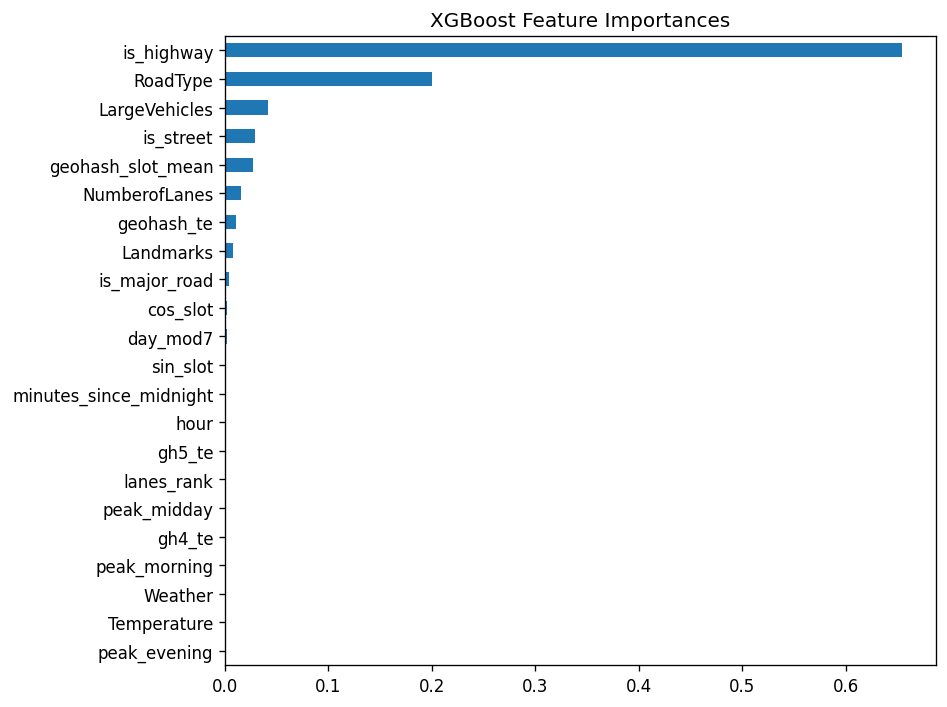

is_highway               0.6548
RoadType                 0.2004
LargeVehicles            0.0420
is_street                0.0288
geohash_slot_mean        0.0273
NumberofLanes            0.0151
geohash_te               0.0105
Landmarks                0.0076
is_major_road            0.0036
cos_slot                 0.0018
day_mod7                 0.0014
sin_slot                 0.0011
minutes_since_midnight   0.0011
hour                     0.0010
gh5_te                   0.0008
lanes_rank               0.0007
peak_midday              0.0007
gh4_te                   0.0007
peak_morning             0.0002
Weather                  0.0001
Temperature              0.0001
peak_evening             0.0001


In [13]:
# Feature importances
fi = pd.Series(
    final_model.feature_importances_,
    index=X_full.columns,
    name='importance',
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind='barh', ax=ax)
ax.set_title('XGBoost Feature Importances')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(fi.to_string())


In [ ]:
# Persist artifacts for reproducibility
artifacts = {
    'model':        final_model,
    'encoders':     enc_full,
    'use_logit':    False,
    'holdout_r2':   best_r2,
    'feature_cols': list(X_full.columns),
    'best_iter':    best_iter,
    'model_type':   'XGBoost',
    'best_params':  best_params,
}
joblib.dump(artifacts, MODEL_DIR / 'artifacts.pkl')
print(f'Artifacts saved -> models/artifacts.pkl')
print(f'Holdout R2 = {best_r2:.6f}  |  Competition score = {max(0, 100*best_r2):.2f}')
print(f'Improvement vs baseline: +{max(0, 100*best_r2) - BASELINE:.2f} pts')


## 8. Predict on Test & Save Submission

In [ ]:
X_test, _ = build_features(test, encoders=enc_full)
preds = np.clip(final_model.predict(X_test), 0.0, 1.0)

print('Prediction statistics:')
print(f'  min    = {preds.min():.6f}')
print(f'  max    = {preds.max():.6f}')
print(f'  mean   = {preds.mean():.6f}')
print(f'  median = {np.median(preds):.6f}')
print(f'  std    = {preds.std():.6f}')


In [16]:
submission = test[['Index']].copy().reset_index(drop=True)
submission['demand'] = preds

out_path = SUBMISSIONS_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)
print(f'Saved -> {out_path}  ({len(submission):,} rows)')
submission.head(10)


Saved -> submissions\submission.csv  (41,778 rows)


,Index,demand
0,0,0.0531
1,1,0.0466
2,2,0.0576
3,3,0.0716
4,4,0.0981
5,5,0.0465
6,6,0.0469
7,7,0.1743
8,8,0.0415
9,9,0.0782


In [ ]:
submission = test[['Index']].copy().reset_index(drop=True)
submission['demand'] = preds

out_path = SUBMISSIONS_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)

# Assertions
assert submission.shape == (41778, 2), f'Shape mismatch: {submission.shape}'
assert list(submission.columns) == ['Index', 'demand']
assert submission['demand'].between(0, 1).all(), 'Demand out of [0,1]'

print(f'Saved -> {out_path}  ({len(submission):,} rows)')

# Sanity check: predicted distribution should resemble train demand
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train[TARGET].hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].set_title('Train Demand Distribution')
submission['demand'].hist(bins=50, ax=axes[1], alpha=0.7, color='orange')
axes[1].set_title('Predicted Demand Distribution')
for ax in axes:
    ax.set_xlabel('demand')
plt.tight_layout()
plt.show()

print()
print('=' * 50)
print(f'  Final Competition Score : {max(0, 100*best_r2):.2f} / 100')
print(f'  Baseline                : {BASELINE:.2f} / 100')
print(f'  Improvement             : +{max(0, 100*best_r2) - BASELINE:.2f} pts')
print(f'  Submission rows         : {len(submission):,}')
print(f'  Demand range            : [{preds.min():.4f}, {preds.max():.4f}]')
print('=' * 50)
